In [1]:
import utils.file as futils
import utils.data as datutils
import utils.score as score
import utils.corrs as corrs
import utils.plots as plots
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.cosmology import Planck13
import importlib
import warnings
from pandas.errors import ParserWarning

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"
plt.style.use('tableau-colorblind10')
colors = [
    '#000000',      # Black
    '#0072B2',      # Blue
    '#009E73',      # Bluish Green
    '#F0E442',      # Yellow
    '#CC79A7',      # Reddish Purple
    '#D55E00',      # Vermilion
    '#56B4E9',      # Sky Blue
    '#E69F00'       # Orange
]

In [2]:
def plot_split(axs, mah_25, mah_50, mah_75, l25, u25, time, indx):
    axs.set_xlabel('Scale Factor a = 1/(1+z)')
    axs.set_ylabel('m(a)')

    for i, mah in enumerate(mah_25):
        if i == 0:
            axs.plot(time, mah,
                    color='blue', alpha=0.3, lw=1)
        else:
            axs.plot(time, mah,
                    color='blue', alpha=0.3, lw=1)

    for i, mah in enumerate(mah_75):
        if i == 0:
            axs.plot(time, mah,
                    color='red', alpha=0.3, lw=1)
        else:
            axs.plot(time, mah,
                    color='red', alpha=0.3, lw=1)
            
    # axs.plot(
    #     time, mah_50[0],
    #     color='green', lw=3, label='median'
    # )


    # Lower 25%
    axs.plot(
        time, l25[1],
        color='blue', lw=3, label='lower 25%'
    )
    # fill between 16th and 84th percentiles
    axs.fill_between(   
        time, l25[0], l25[2],
        color='blue', alpha=0.25, linewidth=0
    )

    # Upper 25%
    axs.plot(
        time, u25[1],
        color='red', lw=3, label='upper 25%'
    )
    # fill between 16th and 84th percentiles
    axs.fill_between(
        time, u25[0], u25[2],
        color='red', alpha=0.25, linewidth=0
    )

    axs.vlines(time[indx], ymin=-1, ymax=1.5, color='k', ls='--')
    axs.set_ylim(0.0, 1.01)
    axs.legend()

In [3]:
# Load data

mah_dict = futils.get_mah_all()
ma, _, aexp_bins = datutils.interp_ma(mah_dict)
am, mass_bins = datutils.build_am(ma=ma, scales=aexp_bins,
                                  min_mass_bin=0.01, log_spacing=True)

stacked_ma = np.vstack([ma]*3)  # because we have 3 projections
stacked_am = np.vstack([am]*3)  # because we have 3 projections

halo_ids = np.array([int(k) for k in mah_dict.keys()])
m14 = futils.get_m14(halo_ids)
m14_stacked = np.hstack([m14['proj_x'], m14['proj_y'], m14['proj_z']])
m14_xyz = pd.concat([m14['proj_x'], m14['proj_y'], m14['proj_z']], axis=0)
m14_xyz.name = 'm14'
m14_xyz.reset_index(drop=False)

dsdf = futils.get_ds(halo_ids)
dsdf.drop(columns=['eta_500[8]', 'delta_500[9]',
          'fm_500[10]', 'fm2_500[11]'], inplace=True)
dsdf.reset_index(inplace=True)
smdf = futils.get_morphologies(halo_ids)
inner_df = futils.get_morphologies(halo_ids, 'r_0.03Mpc_205.csv')
iconc = inner_df['C']
iconc.name = 'core_C'

ahf = futils.get_ahf_all()
mass = np.array([ahf[halo_id]['Mvir(4)'][ahf[halo_id]['Redshift(0)'] == 0].values[0]
                 for halo_id in halo_ids])
logmass = np.log10(mass)
logmass_stacked = np.hstack([logmass]*3)  # because we have 3 projections

n_halos = len(am)
assert m14_stacked.shape[0] == 3 * n_halos
assert stacked_am.shape[0] == 3 * n_halos
assert stacked_ma.shape[0] == 3 * n_halos
assert smdf.shape[0] == 3 * n_halos
assert iconc.shape[0] == 3 * n_halos

/Users/kabelo/clusters/utils/data.py:342: RuntimeWarning: invalid value encountered in log
  np.log(_m_peaks), np.log(_scales), bounds_error=False, fill_value=np.nan


In [4]:
# Calculate lookback time in units of dynamical time
t_d = (3.0857e19)/(10*Planck13.H0.value*60*60*24*365e9)
print(f'Dynamical time = {t_d:.2f} Gyr')

redshift_list = pd.read_csv('data/gadgetx3k/redshift_list.txt', sep=r'\s+')
scales = redshift_list['a'].values
redshifts = redshift_list['z'].values
lookback_time = Planck13.lookback_time(redshifts).value  # in Gyr
lookback_time_td = lookback_time / t_d

Dynamical time = 1.44 Gyr


# Spearman Coefficients

## Morphology

In [5]:
df = pd.concat([smdf[410:], iconc[410:], m14_xyz[410:]], axis=1)

start = time.time()
ma_sm_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, df)
am_sm_dict = datutils.prepare_am_corrs(
    am, masses=mass_bins, df0=df)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
end = time.time()
print(f'{end-start:.1f}s')

6.5s


In [6]:
rho = score.build_rho(df=df, mah=ma)   # corrs as function of mah
wsum_sm = score.wsum(xng=df, weights=rho)  # scores as function of mah

In [7]:
scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.5, wsum=wsum_sm)

mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.7, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.8, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.85, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.9, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

Difference in m(a) between upper and lower 25% medians at a=0.505: 0.1703
Difference in m(a) between upper and lower 25% medians at a=0.697: 0.3712
Difference in m(a) between upper and lower 25% medians at a=0.752: 0.4032
Difference in m(a) between upper and lower 25% medians at a=0.798: 0.3938
Difference in m(a) between upper and lower 25% medians at a=0.853: 0.3066
Difference in m(a) between upper and lower 25% medians at a=0.899: 0.2543


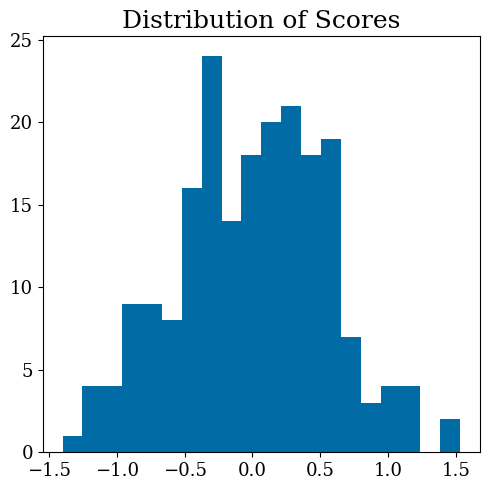

In [8]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

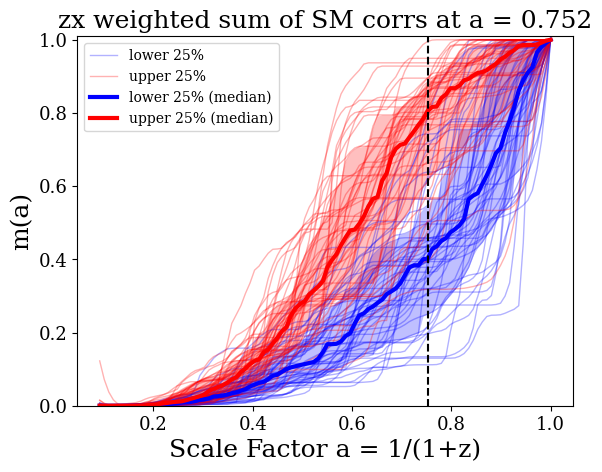

In [9]:
scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.75, wsum=wsum_sm)

mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'zx weighted sum of SM corrs at a = {aexp_bins[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    aexp_bins, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    aexp_bins, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    aexp_bins, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    aexp_bins, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(aexp_bins[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

## Dynamical State

In [10]:
df = pd.concat([dsdf, m14['3d']], axis=1)

start = time.time()
ma_ds_dict, _ = datutils.prepare_ma_corrs(
    mah_dict, df)

am_ds_dict = datutils.prepare_am_corrs(
    am, masses=mass_bins, df0=df)
end = time.time()
print(f'{end-start:.1f}s')

7.2s


In [15]:
# corrs as function of mah
rho = score.build_rho(df=df, mah=ma)
wsum_ds = score.wsum(xng=df, weights=rho)  # scores as function of mah

In [16]:
scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.5, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.7, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.8, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.85, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

scores, indx = score.calc_score(
    # scores at target time, target time index
    time=aexp_bins, target=0.9, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

Difference in m(a) between upper and lower 25% medians at a=0.505: 0.1478
Difference in m(a) between upper and lower 25% medians at a=0.697: 0.3703
Difference in m(a) between upper and lower 25% medians at a=0.752: 0.3978
Difference in m(a) between upper and lower 25% medians at a=0.798: 0.4302
Difference in m(a) between upper and lower 25% medians at a=0.853: 0.4082
Difference in m(a) between upper and lower 25% medians at a=0.899: 0.3174


In [17]:
# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores, verbose=False)  # split mah into lower and upper 25%

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

Difference in m(a) between upper and lower 25% medians at a=0.752: 0.3978


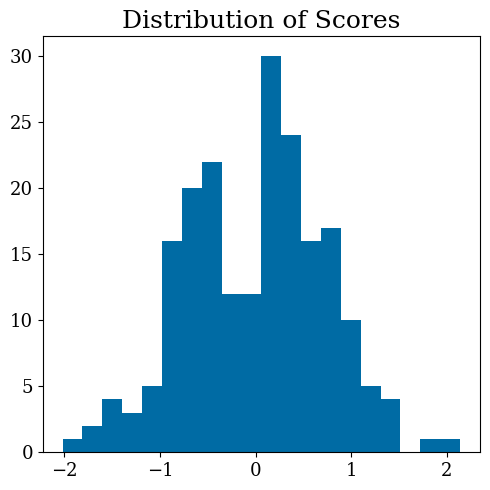

In [18]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

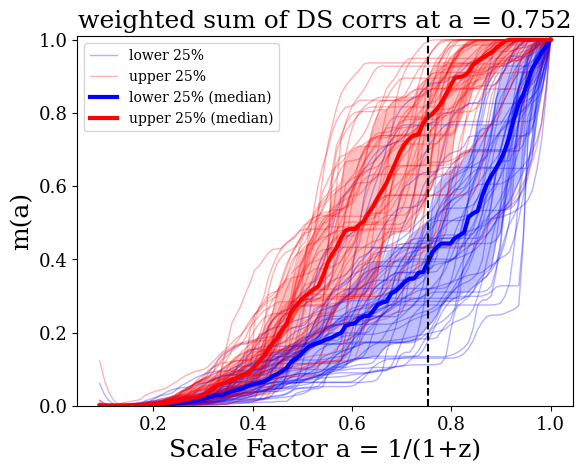

In [19]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of DS corrs at a = {aexp_bins[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    aexp_bins, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    aexp_bins, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    aexp_bins, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    aexp_bins, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(aexp_bins[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

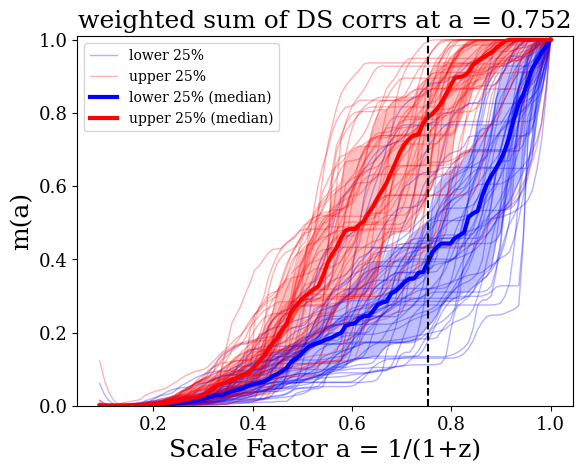

In [20]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of DS corrs at a = {aexp_bins[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    aexp_bins, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    aexp_bins, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    aexp_bins, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    aexp_bins, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(aexp_bins[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

# MultiCAM Training Coefficients

## Dynamical State

In [27]:
df = pd.concat([dsdf.reset_index(), m14['3d']], axis=1)

start = time.time()
x = df.to_numpy()
y = ma
t, _, _, _, ds_weights, _, _, model = corrs.multicorr(x, y, scoring=True)
end = time.time()
print(f'{end - start:.1f}s')

2.2s


In [28]:
wsum_ds = score.wsum(xng=x, model=model, weights=ds_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores, verbose=False)  # split mah into lower and upper 25%

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

Difference in m(a) between upper and lower 25% medians at a=0.752: 0.4080


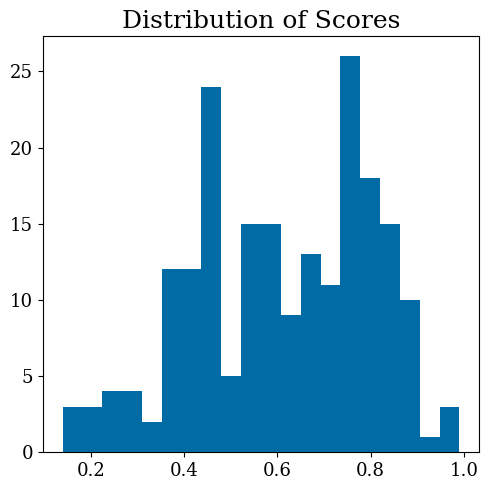

In [29]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

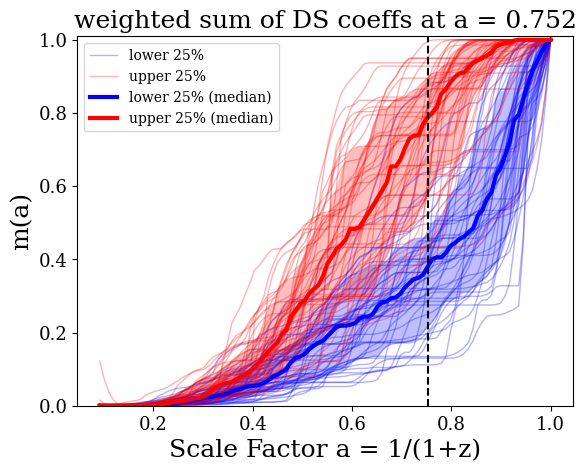

In [30]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of DS coeffs at a = {aexp_bins[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    aexp_bins, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    aexp_bins, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    aexp_bins, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    aexp_bins, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(aexp_bins[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

In [34]:
# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.5, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance = {}

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.7, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.8, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.85, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.9, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

Distance between upper and lower 25% at a=0.505: 0.1650
Distance between upper and lower 25% at a=0.697: 0.3893
Distance between upper and lower 25% at a=0.752: 0.4080
Distance between upper and lower 25% at a=0.798: 0.4364
Distance between upper and lower 25% at a=0.853: 0.4233
Distance between upper and lower 25% at a=0.899: 0.3395


## Morphologies

In [42]:
df = pd.concat([smdf[410:], m14_xyz[410:], iconc[410:]], axis=1)
start = time.time()
x = df.to_numpy()
y = stacked_ma
_, _, _, _, sm_weights, _, _, model = corrs.multicorr(x, y, scoring=True)
end = time.time()
print(f'{end - start:.1f}s')

2.1s


In [44]:
wsum_sm = score.wsum(xng=df, weights=sm_weights, model=model)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores, verbose=False)  # split mah into lower and upper 25%

diff = u25[1][indx] - l25[1][indx]
print(
    f'Difference in m(a) between upper and lower 25% medians at a={aexp_bins[indx]:.3g}: {diff:.4f}')

Difference in m(a) between upper and lower 25% medians at a=0.752: 0.4032


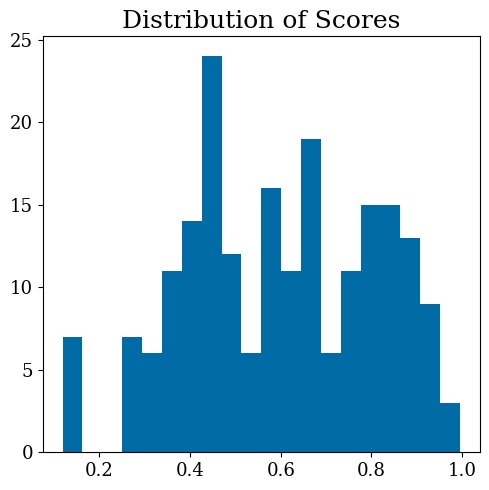

In [45]:
fig, axs = plt.subplots(1, 1, figsize=(5, 5))
axs.hist(scores, bins=20)
axs.set_title('Distribution of Scores')
plt.tight_layout()
plt.show()

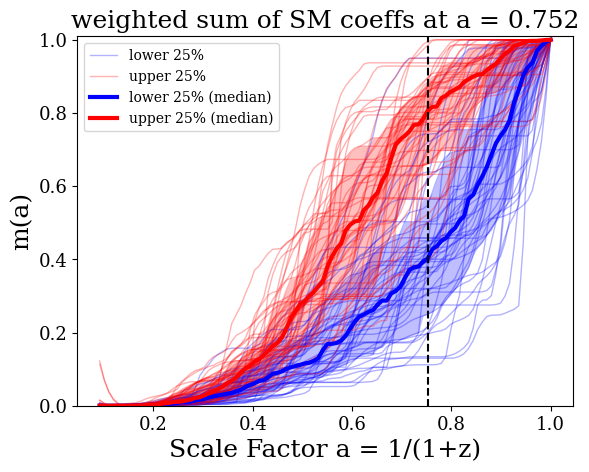

In [46]:
fig, axs = plt.subplots(1, 1)
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('m(a)')
axs.set_title(
    f'weighted sum of SM coeffs at a = {aexp_bins[indx]:.3g}')

for i, mah in enumerate(mah_25):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1, label='lower 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='blue', alpha=0.3, lw=1)

for i, mah in enumerate(mah_75):
    if i == 0:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1, label='upper 25%')
    else:
        axs.plot(aexp_bins, mah,
                 color='red', alpha=0.3, lw=1)
# Lower 25%
axs.plot(
    aexp_bins, l25[1],
    color='blue', lw=3, label='lower 25% (median)'
)
axs.fill_between(
    aexp_bins, l25[0], l25[2],
    color='blue', alpha=0.25, linewidth=0
)

# Upper 25%
axs.plot(
    aexp_bins, u25[1],
    color='red', lw=3, label='upper 25% (median)'
)
axs.fill_between(
    aexp_bins, u25[0], u25[2],
    color='red', alpha=0.25, linewidth=0
)

axs.vlines(aexp_bins[indx], ymin=-1, ymax=1.5, color='k', ls='--')
axs.set_ylim(0.0, 1.01)
axs.legend()
plt.show()

In [47]:
wsum_ds = score.wsum(xng=df, model=model, weights=sm_weights)  # scores as function of mah
distance = {}

# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.5, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%


distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.7, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.8, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.85, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

scores, indx = score.calc_score(time=aexp_bins, target=0.9, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%

distance[aexp_bins[indx]] = u25[1][indx] - l25[1][indx]
print(
    f'Distance between upper and lower 25% at a={aexp_bins[indx]:.3g}: {distance[aexp_bins[indx]]:.4f}')

Distance between upper and lower 25% at a=0.505: 0.1703
Distance between upper and lower 25% at a=0.697: 0.4027
Distance between upper and lower 25% at a=0.752: 0.4032
Distance between upper and lower 25% at a=0.798: 0.4010
Distance between upper and lower 25% at a=0.853: 0.3066
Distance between upper and lower 25% at a=0.899: 0.2623


# Big plot

In [54]:
# Prepare all data
df = pd.concat([dsdf, m14['3d']], axis=1)
x = df.to_numpy()
y = ma
_, _, _, _, ds_weights, ds_rmse, ds_r2 = corrs.multicorr(x, y)
wsum_ds = score.wsum(xng=df, weights=ds_weights)  # scores as function of mah
# scores at target time, target time index
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)  # split mah into lower and upper 25%
mcam_ds = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)

df = pd.concat([smdf[410:], m14_xyz[410:], iconc[410:]], axis=1)
x = df.to_numpy()
y = ma
_, _, _, _, sm_weights, sm_rmse, sm_r2 = corrs.multicorr(x, y)
wsum_sm = score.wsum(xng=df, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)

df = pd.concat([dsdf, m14['3d']], axis=1)
ma_ds_dict, _ = datutils.prepare_ma_corrs(
    mah_dict, df)
am_ds_dict = datutils.prepare_am_corrs(
    am, masses=mass_bins, df0=df)
rho = score.build_rho(df=df, mah=ma)
wsum_ds = score.wsum(xng=df, weights=rho)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_ds)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
rho_ds = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)

df = pd.concat([smdf[410:], m14_xyz[410:], iconc[410:]], axis=1)
ma_sm_dict, filtered_z_list = datutils.prepare_ma_corrs(
    mah_dict, df)
am_sm_dict = datutils.prepare_am_corrs(
    am, masses=mass_bins, df0=df)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)
rho = score.build_rho(df=df, mah=ma)
wsum_sm = score.wsum(xng=df, weights=rho)
scores, indx = score.calc_score(
    time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
rho_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)

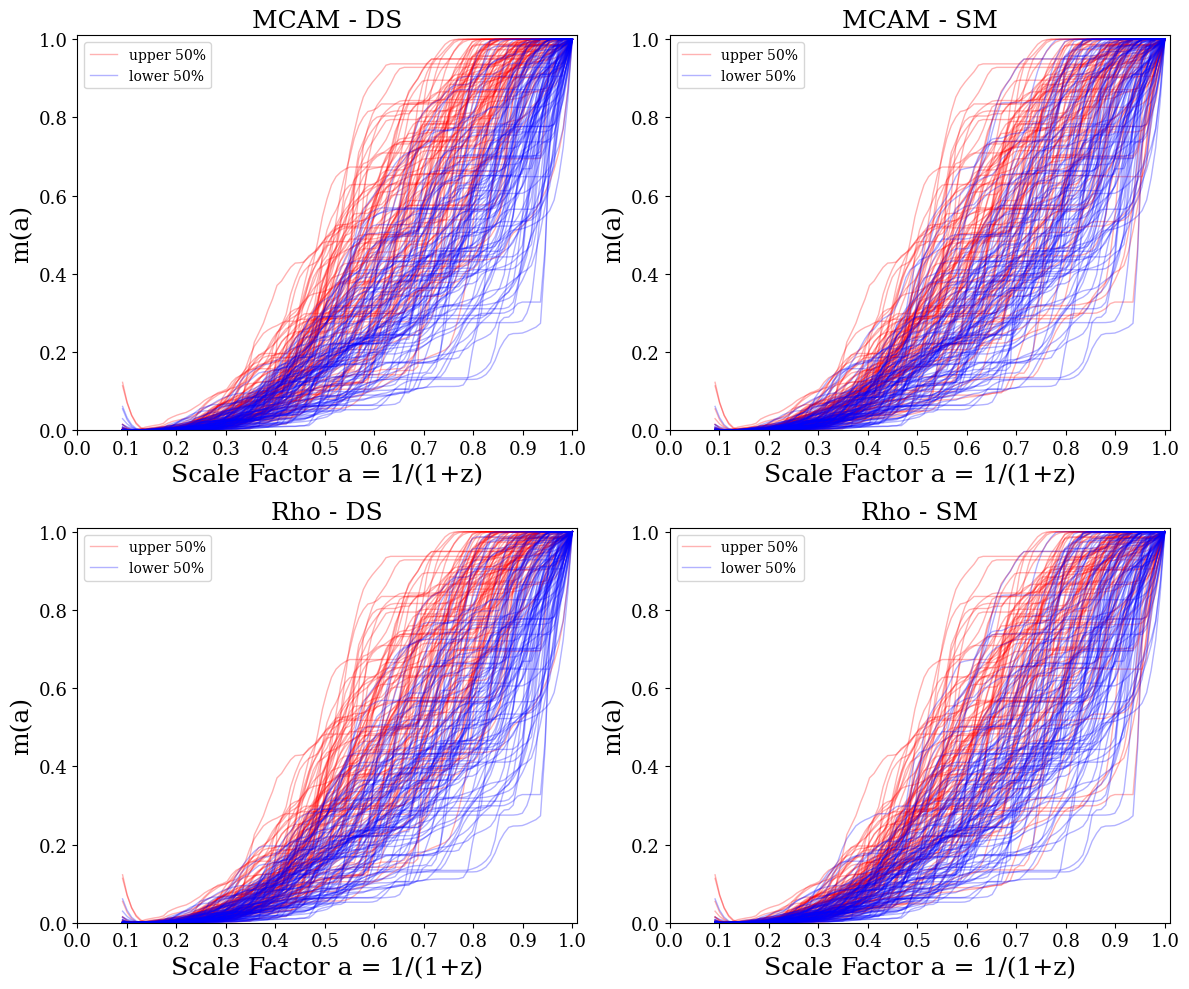

In [55]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
xticks = np.arange(0, 1.1, 0.1)
xlim = (0, 1.01)
ylim = (0., 1.01)

for i, mah in enumerate(mcam_ds[5]):
    if i == 0:
        axs[0, 0].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1, label='upper 50%')
    else:
        axs[0, 0].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1)
        
for i, mah in enumerate(mcam_ds[6]):
    if i == 0:
        axs[0, 0].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1, label='lower 50%')
    else:
        axs[0, 0].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1)
        
axs[0, 0].legend()
axs[0, 0].set_title('MCAM - DS')
axs[0, 0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0, 0].set_ylabel('m(a)')
axs[0, 0].set_xticks(xticks)
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_ylim(ylim)

for i, mah in enumerate(mcam_sm[5]):
    if i == 0:
        axs[0, 1].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1, label='upper 50%')
    else:
        axs[0, 1].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1)
        
for i, mah in enumerate(mcam_sm[6]):
    if i == 0:
        axs[0, 1].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1, label='lower 50%')
    else:
        axs[0, 1].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1)

axs[0, 1].legend()
axs[0, 1].set_title('MCAM - SM')
axs[0, 1].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0, 1].set_ylabel('m(a)')
axs[0, 1].set_xticks(xticks)
axs[0, 1].set_xlim(xlim)
axs[0, 1].set_ylim(ylim)

for i, mah in enumerate(rho_ds[5]):
    if i == 0:
        axs[1, 0].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1, label='upper 50%')
    else:
        axs[1, 0].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1)
        
for i, mah in enumerate(rho_ds[6]):
    if i == 0:
        axs[1, 0].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1, label='lower 50%')
    else:
        axs[1, 0].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1)
axs[1, 0].legend()
axs[1, 0].set_title('Rho - DS')
axs[1, 0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[1, 0].set_ylabel('m(a)')
axs[1, 0].set_xticks(xticks)
axs[1, 0].set_xlim(xlim)
axs[1, 0].set_ylim(ylim)

for i, mah in enumerate(rho_sm[5]):
    if i == 0:
        axs[1, 1].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1, label='upper 50%')
    else:
        axs[1, 1].plot(aexp_bins, mah,
                       color='red', alpha=0.3, lw=1)

for i, mah in enumerate(rho_sm[6]):
    if i == 0:
        axs[1, 1].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1, label='lower 50%')
    else:
        axs[1, 1].plot(aexp_bins, mah,
                       color='blue', alpha=0.3, lw=1)
axs[1, 1].legend()
axs[1, 1].set_title('Rho - SM')
axs[1, 1].set_xlabel('Scale Factor a = 1/(1+z)')
axs[1, 1].set_ylabel('m(a)')
axs[1, 1].set_xticks(xticks)
axs[1, 1].set_xlim(xlim)
axs[1, 1].set_ylim(ylim)
plt.tight_layout()
plt.show()

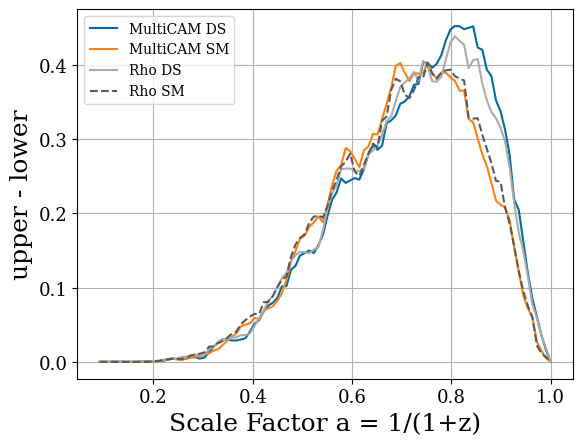

In [56]:
fig, axs = plt.subplots(1, 1)
mcam_ds_diff = mcam_ds[4][1][:] - mcam_ds[3][1][:]
axs.plot(aexp_bins, mcam_ds_diff, label='MultiCAM DS')
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs.plot(aexp_bins, mcam_sm_diff, label='MultiCAM SM')
rho_ds_diff = rho_ds[4][1][:] - rho_ds[3][1][:]
axs.plot(aexp_bins, rho_ds_diff, label='Rho DS')
rho_sm_diff = rho_sm[4][1][:] - rho_sm[3][1][:]
axs.plot(aexp_bins, rho_sm_diff, label='Rho SM', ls='--')
axs.set_xlabel('Scale Factor a = 1/(1+z)')
axs.set_ylabel('upper - lower')
axs.legend()
axs.grid()
plt.show()

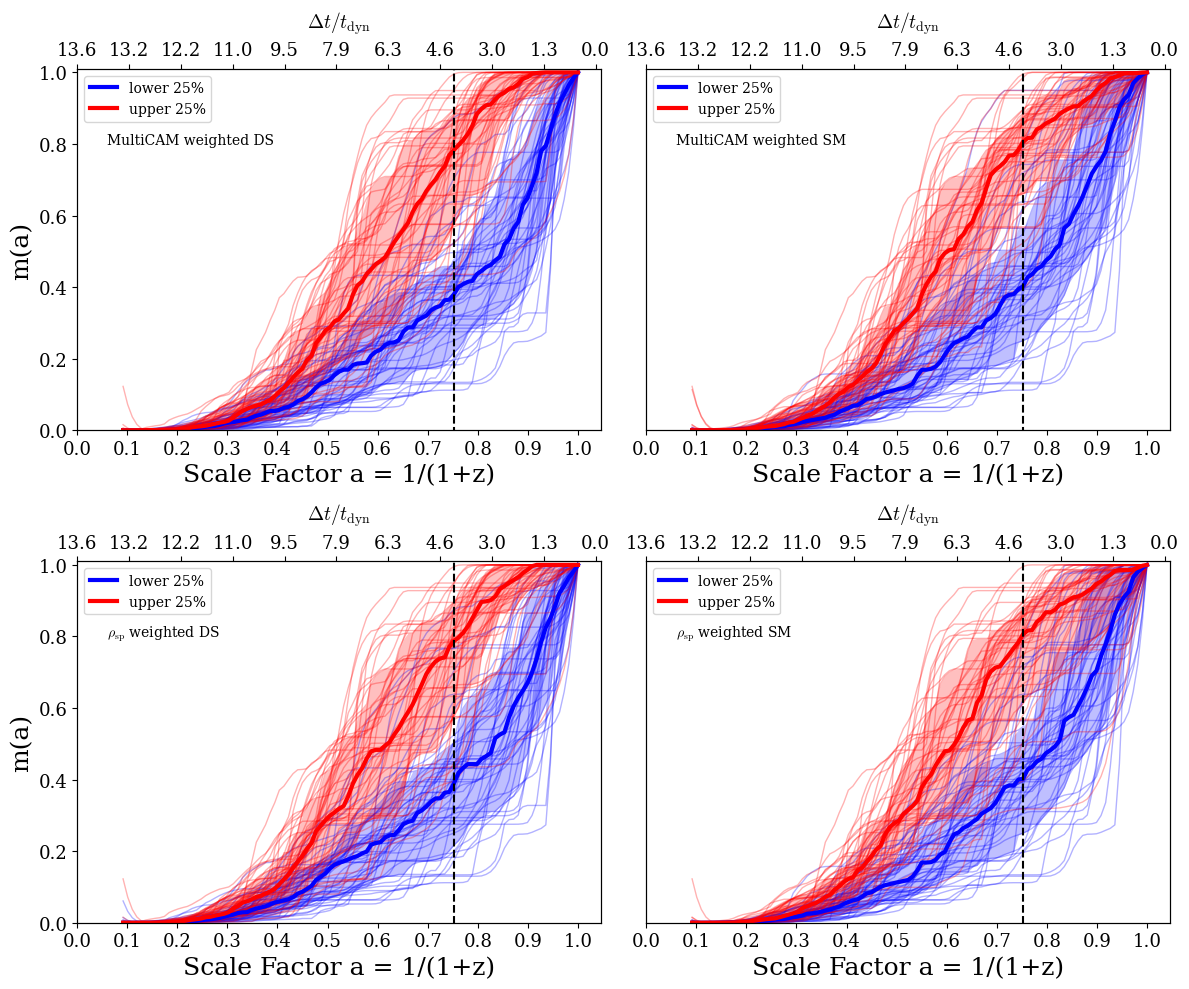

In [57]:
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
xticks = np.arange(0, 1.1, 0.1)
xlim = (0, 1.01)
ylim = (0., 1.01)

plot_split(axs[0, 0], mcam_ds[0], mcam_ds[1], mcam_ds[2],
           mcam_ds[3], mcam_ds[4], aexp_bins, indx)
# axs[0, 0].xaxis.set_visible(False)
axs[0, 0].annotate(text=r'MultiCAM weighted DS', xy=(0.06, 0.8))
axs[0, 0].set_xticks(xticks)
# axs[0, 0].xaxis.label.set_visible(False)


plot_split(axs[0, 1], mcam_sm[0], mcam_sm[1], mcam_sm[2],
           mcam_sm[3], mcam_sm[4], aexp_bins, indx)
# axs[0, 1].xaxis.set_visible(False)
axs[0, 1].yaxis.set_visible(False)
axs[0, 1].annotate(text=r'MultiCAM weighted SM', xy=(0.06, 0.8))
axs[0, 1].set_xticks(xticks)
# axs[0, 1].xaxis.label.set_visible(False)

plot_split(axs[1, 0], rho_ds[0], rho_ds[1], rho_ds[2],
           rho_ds[3], rho_ds[4], aexp_bins, indx)
axs[1, 0].annotate(text=r'$\rho_{\mathrm{sp}}$ weighted DS', xy=(0.06, 0.8))
axs[1, 0].set_xticks(xticks)
plot_split(axs[1, 1], rho_sm[0], rho_sm[1], rho_sm[2],
           rho_sm[3], rho_sm[4], aexp_bins, indx)
axs[1, 1].annotate(text=r'$\rho_{\mathrm{sp}}$ weighted SM', xy=(0.06, 0.8))
axs[1, 1].yaxis.set_visible(False)
axs[1, 1].set_xticks(xticks)
plots.plot_dynamical_time(
    axs=axs, xlim=xlim, xticks=xticks, scales=scales, lookback_time=lookback_time)

plt.tight_layout()
# plt.savefig('plots/mah_split.pdf')
plt.show()

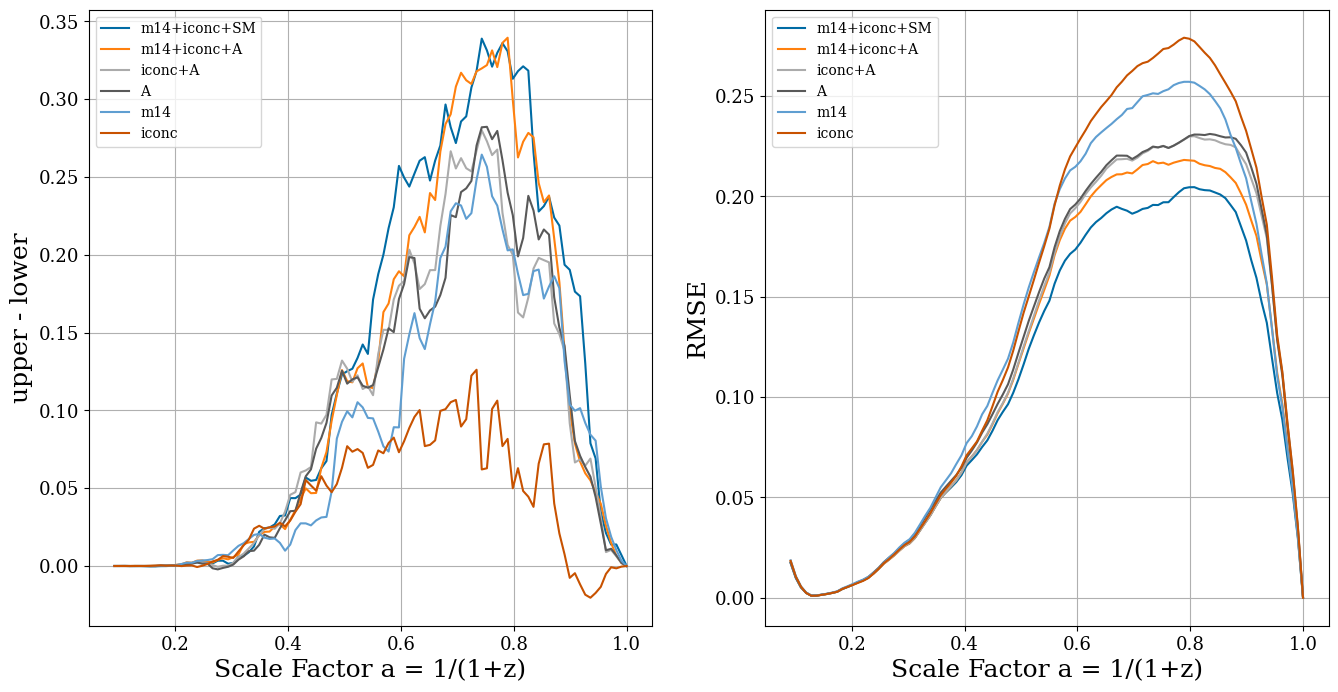

In [59]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8))

x = np.vstack([smdf['rhalf_circ'], smdf['C'], smdf['A'],
               smdf['sersic_amplitude'], iconc, m14_stacked]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
# mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='m14+iconc+SM')
axs[1].plot(aexp_bins, sm_rmse, label='m14+iconc+SM')

x = np.vstack([smdf['A'], iconc, m14_stacked]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='m14+iconc+A')
axs[1].plot(aexp_bins, sm_rmse, label='m14+iconc+A')

x = np.vstack([smdf['A'], iconc]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='iconc+A')
axs[1].plot(aexp_bins, sm_rmse, label='iconc+A')
    
x = np.vstack([smdf['A']]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='A')
axs[1].plot(aexp_bins, sm_rmse, label='A')

x = np.vstack([m14_stacked]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='m14')
axs[1].plot(aexp_bins, sm_rmse, label='m14')

x = np.vstack([iconc]).T
y = stacked_ma
_, _, _, _, sm_weights, sm_rmse, r2, model = corrs.multicorr(x, y, scoring=True)
wsum_sm = score.wsum(xng=x, model=model, weights=sm_weights)
scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50 = score.split_mah(
    mah_dict, scores)
mcam_sm = (mah_25, mah_50, mah_75, l25, u25, mah_u50, mah_l50)
mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
axs[0].plot(aexp_bins, mcam_sm_diff, label='iconc')
axs[1].plot(aexp_bins, sm_rmse, label='iconc')

# df = pd.concat([sm_df_zx['A'], sm_df_zx['C'], m14['proj_z']], axis=1)
# x = df.to_numpy()
# y = ma
# _, _, _, _, sm_weights, sm_rmse = corrs.multicorr(x, y)
# wsum_sm = score.wsum(x=df, weights=sm_weights)
# scores, indx = score.calc_score(time=aexp_bins, target=0.75, wsum=wsum_sm)
# mah_25, mah_50, mah_75, l25, u25 = score.split_mah(
#     mah_dict, scores)
# mcam_sm = (mah_25, mah_50, mah_75, l25, u25)
# mcam_sm_diff = mcam_sm[4][1][:] - mcam_sm[3][1][:]
# axs[0].plot(aexp_bins, mcam_sm_diff, label='A+C+m14')
# axs[1].plot(aexp_bins, sm_rmse, label='A+C+m14')


axs[0].set_xlabel('Scale Factor a = 1/(1+z)')
axs[0].set_ylabel('upper - lower')
axs[0].legend()
axs[0].grid()
axs[1].set_xlabel('Scale Factor a = 1/(1+z)')
axs[1].set_ylabel('RMSE')
axs[1].legend()
axs[1].grid()

In [9]:
np.shape(mah_u50), np.shape(u25)

((96, 100), (3, 100))

# Exploration

In [74]:
%%time
df = pd.concat([dsdf, m14['3d']], axis=1)

x = df.to_numpy()
y = ma
t, _, _, _, ds_weights, _, _ = corrs.multicorr(x, y)

CPU times: user 2.13 s, sys: 66.3 ms, total: 2.19 s
Wall time: 2.22 s


In [78]:
wsum_ds = score.wsum(x=df, weights=ds_weights)  # scores as function of mah
scores, indx = score.calc_score(time=aexp_bins, target=0.9, wsum=wsum_ds)
split_dict = score.split_mah_idx(mah_dict, scores)
# split_dict

In [79]:
halos = futils.get_ahf_all()
masses = np.array([(k, df['Mvir(4)'].loc[df['Redshift(0)'] == 0].values[0]) for k, df in halos.items()])
# masses

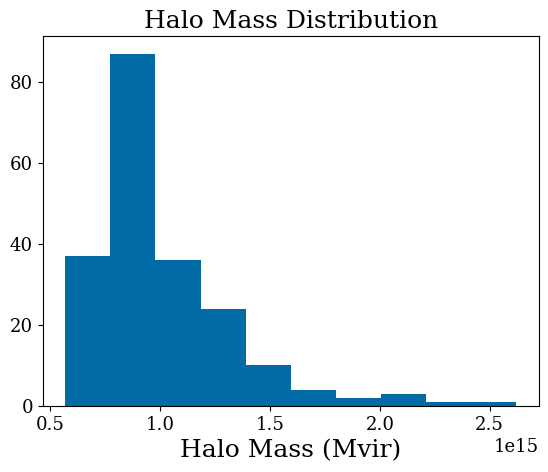

In [80]:
plt.hist(masses[:, 1])
plt.title('Halo Mass Distribution')
plt.xlabel('Halo Mass (Mvir)')
plt.show()

In [61]:
ml25 = [m for idx, m in mass_bins if idx in split_dict['lower_25']]
mu25 = [m for idx, m in mass_bins if idx in split_dict['upper_25']]
plt.hist(ml25, histtype='step', label='lower 25%')
plt.hist(mu25, histtype='step', label='upper 25%')

# ml50 = [m for idx, m in masses if idx in split_dict['lower_50']]
# mu50 = [m for idx, m in masses if idx in split_dict['upper_50']]
# plt.hist(ml50, histtype='step', label='lower 50%')
# plt.hist(mu50, histtype='step', label='upper 50%')

plt.title('MCAM DS Split| a = 0.75')
plt.xlabel('Halo Mass (Mvir)')
plt.legend()
plt.show()

TypeError: cannot unpack non-iterable numpy.float64 object